The goal is to obtain samples from the boltzmann distribution: example a double well potential with a fast and slow variable. (2 dim)

In [568]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

COSTRINCTING THE FLOW:
3 upling flow where s and t are mlp, for a total of 6 mlp to train.

In [569]:
def init_mlp_params(key, in_dim, hidden_dim, out_dim):
    k1, k2, k3 = jax.random.split(key, 3)
    return {
        "W1": jax.random.normal(k1, (in_dim, hidden_dim))*0.01,
        "b1": jnp.zeros((hidden_dim,)),
        "W2": jax.random.normal(k2, (hidden_dim, hidden_dim))*0.01,
        "b2": jnp.zeros((hidden_dim,)),
        "W3": jax.random.normal(k3, (hidden_dim, out_dim))*0.01,
        "b3": jnp.zeros((out_dim,)),
    }# Initialize MLP parameters with small random values: weights from a normal distribution and biases as zeros.

#The mlp function defines a simple feedforward neural network with one hidden layer. 
# It takes input x, applies a linear transformation followed by a tanh activation to get the hidden representation h, 
# and then applies another linear transformation to produce the output.
def mlp(params, x):
    h = jnp.tanh(x @ params["W1"] + params["b1"])
    h = jnp.tanh(h @ params["W2"] + params["b2"]) # Add a second hidden layer for more expressiveness
    return h @ params["W3"] + params["b3"]

In [ ]:
def init_params(key):
    keys = jax.random.split(key, 4)
    return {
        "s1": init_mlp_params(keys[0], 1, 32, 1),
        "t1": init_mlp_params(keys[1], 1, 32, 1),
        "s2": init_mlp_params(keys[2], 1, 32, 1),
        "t2": init_mlp_params(keys[3], 1, 32, 1),
        "s3": init_mlp_params(keys[0], 1, 32, 1),
        "t3": init_mlp_params(keys[1], 1, 32, 1)
    }
# The init_params function initializes the parameters for two coupling layers, each with its own scale (s) and translation (t) MLPs.

def permute(x):
    return x[:, ::-1]

def coupling1(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    
    s = mlp(params["s1"], z1)

    t = mlp(params["t1"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling2(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = mlp(params["s2"], z1)

    t = mlp(params["t2"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det

def coupling3(params, z):
    z1 = z[:, 0:1]
    z2 = z[:, 1:2]

    s = mlp(params["s3"], z1)

    t = mlp(params["t3"], z1)

    x1 = z1
    x2 = z2 * jnp.exp(s) + t

    log_det = jnp.sum(s, axis=1)

    x = jnp.concatenate([x1, x2], axis=1)
    return x, log_det


FORWARD FLOW

In [ ]:
def forward(params, z):
    x, log_det1 = coupling1(params, z)
    
    x = permute(x)
    
    x, log_det2 = coupling2(params, x)
    
    log_det = log_det1 + log_det2

    x = permute(x) 

    x, log_det3 = coupling3(params, x)

    log_det += log_det3
    
    return x, log_det

LOG PROBABILITIES

In [572]:
def log_pz(z):
    return -0.5 * jnp.sum(z**2, axis=1)

def log_q_target(x, T):
    x_slow = x[:, 0:1]
    x_fast = x[:, 1:2]
    # Double well in x_slow: minimi in ±1
    energy_slow = (x_slow**2 - 1)**2   # double well potential (variabile lenta)
    energy_fast = x_fast**2             # potenziale armonico (variabile veloce)
    kb = 1.0  # Boltzmann constant
    return (-jnp.sum(energy_slow, axis=1) - 0.5 * jnp.sum(energy_fast, axis=1)) / (kb * T)

LOSS

In [573]:
def loss(params, key, n_samples=1000, T=1.0):
    z = jax.random.normal(key, (n_samples, 2))
    x, log_det = forward(params, z)

    log_p = log_pz(z)
    log_q = log_q_target(x, T)

    return jnp.mean(log_p - log_det - log_q)

TRAINING

Step 0, Loss: 1.0704
Step 100, Loss: 0.5924
Step 200, Loss: 0.6105
Step 300, Loss: 0.6924
Step 400, Loss: 0.5784
Step 500, Loss: 0.6337
Step 600, Loss: 0.6107
Step 700, Loss: 0.6032
Step 800, Loss: 0.5925
Step 900, Loss: 0.6213
Step 1000, Loss: 0.6527
Step 1100, Loss: 0.6188
Step 1200, Loss: 0.6085
Step 1300, Loss: 0.5711
Step 1400, Loss: 0.6012
Step 1500, Loss: 0.5719
Step 1600, Loss: 0.5327
Step 1700, Loss: 0.6132
Step 1800, Loss: 0.5745
Step 1900, Loss: 0.6420
Step 2000, Loss: 0.5406
Step 2100, Loss: 0.6311
Step 2200, Loss: 0.6599
Step 2300, Loss: 0.6335
Step 2400, Loss: 0.6015
Step 2500, Loss: 0.5491
Step 2600, Loss: 0.5407
Step 2700, Loss: 0.5977
Step 2800, Loss: 0.6694
Step 2900, Loss: 0.5660
Step 3000, Loss: 0.6386
Step 3100, Loss: 0.6528
Step 3200, Loss: 0.6423
Step 3300, Loss: 0.6761
Step 3400, Loss: 0.6007
Step 3500, Loss: 0.6492
Step 3600, Loss: 0.7157
Step 3700, Loss: 0.5824
Step 3800, Loss: 0.6143
Step 3900, Loss: 0.5418
Step 4000, Loss: 0.6250
Step 4100, Loss: 0.5899
Step

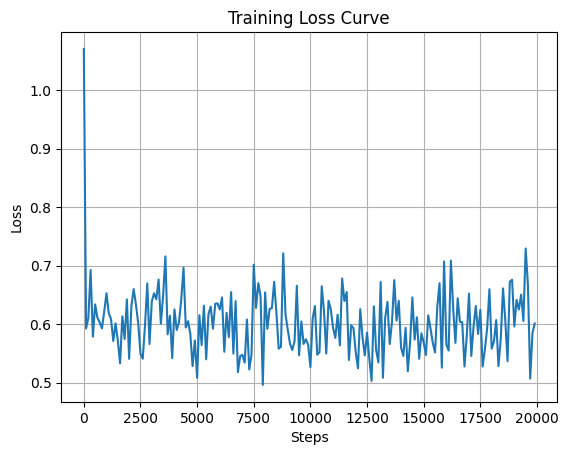

In [574]:
@jax.jit
def step(params, key, lr=1e-3 , n_samples=500, T=1.0):
    l, grads = jax.value_and_grad(loss)(params, key, n_samples=n_samples, T=T)

    new_params = jax.tree.map(
    lambda p, g: p - lr * g,
    params,
    grads )
    return new_params, l

# Initialize parameters
key = jax.random.PRNGKey(0)
key, subkey = jax.random.split(key)
params = init_params(subkey)

n_steps = 20000
lr = 1e-3
losses = []

for i in range(n_steps):
    key, subkey = jax.random.split(key)
    params, l = step(params, subkey, lr)
    if i % 100 == 0:
        losses.append(l)
        print(f"Step {i}, Loss: {l:.4f}")

best_params = params

# plotting loss curve
plt.plot(jnp.arange(0, n_steps, 100), losses)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

SAMPLING

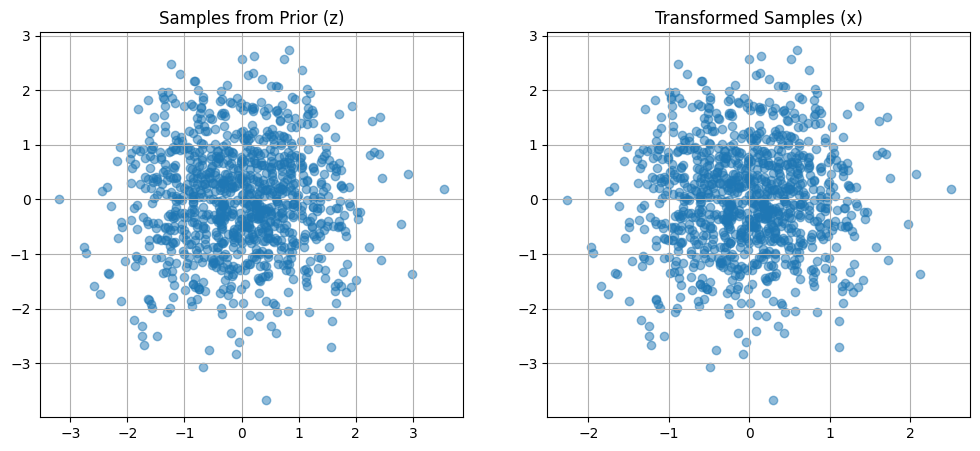

In [575]:
# sampling from prior
key, subkey = jax.random.split(key)
n_samples = 1000
z = jax.random.normal(subkey, (n_samples, 2))
x, _ = forward(best_params, z)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(z[:, 0], z[:, 1], alpha=0.5)
plt.title("Samples from Prior (z)")
plt.grid(True)
plt.subplot(1,2,2)
plt.scatter(x[:, 0], x[:, 1], alpha=0.5)
plt.title("Transformed Samples (x)")
plt.grid(True)
plt.show()